# Pit Stop Submission Blender

This notebook creates a small, controlled set of final blend candidates for the F1 pit stop prediction task. It uses a structured input dataset with public submissions and our CatBoost submissions, then saves only the candidates that are worth testing.

The current best direction is anchored by `b10`: `0.950 public_core + 0.050 public_0.95381`. The new experiment keeps that recipe as the baseline and adds tiny CatBoost variant signals from `shallow.csv` and `reg.csv`, instead of generating many noisy blend files.


In [1]:
"""Import libraries, configure paths, and define notebook display helpers."""

from pathlib import Path
from html import escape
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
from IPython.display import display, HTML

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")

ID_COL = "id"
TARGET_COL = "PitNextLap"
CLIP_LOW = 1e-7
CLIP_HIGH = 1 - 1e-7

DATASET_CANDIDATES = [
    Path("/kaggle/input/pitstop-blend-inputs"),
    Path("/kaggle/input/pit-stop-blend-inputs"),
    Path("/kaggle/input/blend-dataset"),
    Path("/kaggle/input") / "blend_dataset",
    Path("PredictingPitStop/blend_dataset"),
    Path("blend_dataset"),
]

OUTPUT_ROOT = Path("outputs") / "blender"
SUBMISSION_ROOT = OUTPUT_ROOT / "submissions"
REPORT_ROOT = OUTPUT_ROOT / "reports"
for folder in [SUBMISSION_ROOT / "best", SUBMISSION_ROOT / "catboost_variant", SUBMISSION_ROOT / "public_support", REPORT_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)


def find_dataset_dir():
    for path in DATASET_CANDIDATES:
        if (path / "public").exists() and (path / "ours").exists():
            return path
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in sorted(kaggle_input.rglob("*")):
            if path.is_dir() and (path / "public").exists() and (path / "ours").exists():
                return path
    raise FileNotFoundError("Could not find a dataset folder containing public/ and ours/ subfolders.")


def fmt_value(value):
    if pd.isna(value):
        return "-"
    if isinstance(value, (np.integer, int)):
        return f"{int(value):,}"
    if isinstance(value, (np.floating, float)):
        if abs(value) >= 1000:
            return f"{value:,.0f}"
        return f"{value:.6f}".rstrip("0").rstrip(".")
    return str(value)


def show_title(title, subtitle=None):
    subtitle_html = f'<div style="color:#6b7280;font-size:13px;margin-top:3px;">{escape(str(subtitle))}</div>' if subtitle else ""
    display(HTML(
        f"""
        <div style="margin:18px 0 10px 0;padding-bottom:8px;border-bottom:1px solid #e5e7eb;">
          <div style="font-size:18px;font-weight:700;color:#111827;">{escape(str(title))}</div>
          {subtitle_html}
        </div>
        """
    ))


def show_metric_cards(title, data, columns=4):
    cards = []
    for key, value in data.items():
        cards.append(
            f"""
            <div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 12px;background:#ffffff;">
              <div style="font-size:11px;text-transform:uppercase;letter-spacing:.04em;color:#6b7280;">{escape(str(key).replace('_', ' '))}</div>
              <div style="font-size:18px;font-weight:700;color:#111827;margin-top:4px;">{escape(fmt_value(value))}</div>
            </div>
            """
        )
    display(HTML(
        f"""
        <div style="margin:12px 0;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          <div style="display:grid;grid-template-columns:repeat({columns},minmax(0,1fr));gap:8px;">
            {''.join(cards)}
          </div>
        </div>
        """
    ))


def show_table(title, df, max_rows=20):
    view = df.head(max_rows).copy()
    display(HTML(
        f"""
        <div style="margin:12px 0;max-width:1180px;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          {view.to_html(index=False, escape=False, classes='clean-table')}
        </div>
        <style>
          table.clean-table {{border-collapse:collapse;width:100%;font-size:13px;table-layout:auto;}}
          table.clean-table th {{background:#f9fafb;text-align:left;border-bottom:1px solid #e5e7eb;padding:8px;color:#374151;white-space:nowrap;}}
          table.clean-table td {{border-bottom:1px solid #eef2f7;padding:8px;color:#111827;vertical-align:top;}}
          table.clean-table td code {{font-size:12px;}}
        </style>
        """
    ))


## 1. Load Structured Blend Dataset

The notebook reads only the structured blend dataset: `public/*.csv` and `ours/*.csv`. It intentionally avoids scanning all notebook outputs, because old submissions and sample files can pollute the blend groups.


In [2]:
"""Load public and own submission files from the structured blend dataset."""

dataset_dir = find_dataset_dir()

predictions = {}
records = []
base_ids = None


def load_submission(path, source):
    global base_ids
    df = pd.read_csv(path)
    if ID_COL not in df.columns:
        return None
    target_candidates = [col for col in df.columns if col != ID_COL]
    if TARGET_COL in df.columns:
        target_col = TARGET_COL
    elif len(target_candidates) == 1:
        target_col = target_candidates[0]
    else:
        return None

    df = df[[ID_COL, target_col]].rename(columns={target_col: TARGET_COL})
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    if df[TARGET_COL].isna().any() or df[ID_COL].duplicated().any():
        return None

    if base_ids is None:
        base_ids = df[ID_COL].copy()
    elif not base_ids.equals(df[ID_COL]):
        return None

    safe_name = path.stem.replace(".", "_").replace("-", "_")
    name = f"{source}_{safe_name}"
    pred = np.clip(df[TARGET_COL].to_numpy(dtype=float), CLIP_LOW, CLIP_HIGH)
    predictions[name] = pred
    public_score = np.nan
    if source == "public":
        try:
            public_score = float(path.stem)
        except ValueError:
            public_score = np.nan
    return {
        "name": name,
        "source": source,
        "public_score": public_score,
        "group": path.parent.name,
        "rows": len(df),
        "mean": pred.mean(),
        "std": pred.std(),
        "file": str(path.relative_to(dataset_dir)),
    }

for source in ["public", "ours"]:
    for path in sorted((dataset_dir / source).rglob("*.csv")):
        row = load_submission(path, source)
        if row is not None:
            records.append(row)

if not records:
    raise FileNotFoundError("No valid submissions were loaded from the structured dataset.")

input_summary = pd.DataFrame(records).sort_values(["source", "group", "public_score", "name"], ascending=[True, True, False, True]).reset_index(drop=True)
input_summary.to_csv(REPORT_ROOT / "inputs.csv", index=False)

show_title("Loaded blend dataset", f"Dataset folder: {dataset_dir}")
show_metric_cards(
    "Input files",
    {
        "total": len(input_summary),
        "public": int(input_summary["source"].eq("public").sum()),
        "ours": int(input_summary["source"].eq("ours").sum()),
        "rows": len(base_ids),
    },
    columns=4,
)
show_table("Loaded submissions", input_summary[["name", "source", "group", "public_score", "mean", "std", "file"]].round(6), max_rows=30)


name,source,public_score,mean,std,file
ours_base,ours,NaN,0.276797,0.361970,ours/base.csv
ours_prob,ours,NaN,0.276541,0.362038,ours/prob.csv
ours_reg,ours,NaN,0.279956,0.362559,ours/reg.csv
ours_s42,ours,NaN,0.276623,0.362434,ours/s42.csv
ours_s777,ours,NaN,0.276787,0.361862,ours/s777.csv
ours_shallow,ours,NaN,0.285043,0.364456,ours/shallow.csv
public_0_95405,public,0.954050,0.219467,0.316353,public/0.95405.csv
public_0_95404,public,0.954040,0.222861,0.318378,public/0.95404.csv
public_0_95402,public,0.954020,0.226254,0.320474,public/0.95402.csv
public_0_95401,public,0.954010,0.213334,0.312760,public/0.95401.csv


## 2. Build Blend Groups

The groups are deliberately small: a high-score public core, the proven diverse `0.95381` file, one public support file, and our CatBoost variants `shallow` and `reg`.


In [3]:
"""Build the small set of groups used by the final blend candidates."""

public_meta = input_summary[input_summary["source"].eq("public") & input_summary["public_score"].notna()].copy()
public_meta = public_meta.sort_values("public_score", ascending=False)

top_external = input_summary[input_summary["group"].eq("top_external")]["name"].tolist()
public_core = input_summary[input_summary["group"].eq("core")].sort_values("public_score", ascending=False)["name"].head(6).tolist()
if not public_core:
    public_core = public_meta[public_meta["public_score"].ge(0.95388)].head(6)["name"].tolist()
if len(public_core) < 6 and not top_external:
    public_core = public_meta.head(6)["name"].tolist()


def public_by_score(score):
    matches = input_summary[
        input_summary["source"].eq("public")
        & np.isclose(input_summary["public_score"].astype(float), score, atol=1e-8, equal_nan=False)
    ]["name"].tolist()
    return matches

public_diverse = input_summary[input_summary["group"].eq("diverse")]["name"].tolist() or public_by_score(0.95381)
public_support = input_summary[input_summary["group"].eq("support")]["name"].tolist() or public_by_score(0.95305)
own_base = input_summary[input_summary["source"].eq("ours") & input_summary["group"].eq("main")]["name"].tolist()
own_variants = input_summary[input_summary["source"].eq("ours") & input_summary["group"].eq("variants")]["name"].tolist()

if not public_core:
    raise RuntimeError("public_core is empty.")
if not public_diverse:
    raise RuntimeError("Required public 0.95381 file was not found.")

groups = {
    "top_external": top_external,
    "public_core": public_core,
    "public_diverse": public_diverse,
    "public_support": public_support,
    "own_base": own_base,
    "own_variants": own_variants,
}

group_summary = pd.DataFrame(
    [{"group": group, "count": len(names), "members": ", ".join(names) or "-"} for group, names in groups.items()]
)
group_summary.to_csv(REPORT_ROOT / "groups.csv", index=False)

show_title("Blend groups", "Only the files used by final candidates are selected")
show_table("Groups", group_summary, max_rows=len(group_summary))


group,count,members
public_core,6,"public_0_95405, public_0_95404, public_0_95402, public_0_95401, public_0_95400, public_0_95388"
public_diverse,1,public_0_95381
public_support,1,public_0_95305
own_base,2,"ours_prob, ours_base"
own_variants,2,"ours_shallow, ours_reg"


## 3. Create Final Candidates

This block creates only five submissions. `b10` is the known best recipe. `vs`, `vr`, and `vm` test tiny CatBoost variant injections. `ds` tests the small public-support correction.


In [4]:
"""Create the final compact blend candidates and save grouped submission files."""


def mean_predictions(names):
    return np.clip(np.vstack([predictions[name] for name in names]).mean(axis=0), CLIP_LOW, CLIP_HIGH)


def save_submission(path, pred):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({ID_COL: base_ids.values, TARGET_COL: np.clip(pred, CLIP_LOW, CLIP_HIGH)}).to_csv(path, index=False)

core_pred = mean_predictions(groups["public_core"])
diverse_pred = predictions[groups["public_diverse"][0]]
support_pred = predictions[groups["public_support"][0]] if groups["public_support"] else None
top_external_pred = mean_predictions(groups["top_external"]) if groups.get("top_external") else None
shallow_pred = predictions.get("ours_shallow")
reg_pred = predictions.get("ours_reg")

blend_predictions = {}
blend_specs = []


def add_candidate(key, folder, filename, pred, recipe, note, try_order):
    pred = np.clip(pred, CLIP_LOW, CLIP_HIGH)
    blend_predictions[key] = pred
    path = SUBMISSION_ROOT / folder / filename
    save_submission(path, pred)
    blend_specs.append(
        {
            "try": try_order,
            "key": key,
            "group": folder,
            "file": str(path.relative_to(OUTPUT_ROOT)),
            "recipe": recipe,
            "corr_b10": np.nan,
            "delta_b10": np.nan,
            "delta_core": np.abs(pred - core_pred).mean(),
            "mean": pred.mean(),
            "std": pred.std(),
            "note": note,
        }
    )

b10_pred = 0.950 * core_pred + 0.050 * diverse_pred
add_candidate("b10", "best", "b10.csv", b10_pred, "0.950 core + 0.050 95381", "Current best known recipe", 1)

try_order = 2
if top_external_pred is not None:
    add_candidate(
        "tx",
        "top_external",
        "tx.csv",
        top_external_pred,
        "mean(0.95409_a, 0.95409_b)",
        "Mean of new 0.95409 external submissions",
        try_order,
    )
    try_order += 1
    add_candidate(
        "tb",
        "top_external",
        "tb.csv",
        0.900 * top_external_pred + 0.100 * b10_pred,
        "0.900 top_external + 0.100 b10",
        "Conservative blend of top external mean with b10",
        try_order,
    )
    try_order += 1

if shallow_pred is not None:
    add_candidate(
        "vs",
        "catboost_variant",
        "vs.csv",
        0.945 * core_pred + 0.050 * diverse_pred + 0.005 * shallow_pred,
        "0.945 core + 0.050 95381 + 0.005 shallow",
        "Tiny shallow CatBoost injection",
        try_order,
    )
    try_order += 1

if reg_pred is not None:
    add_candidate(
        "vr",
        "catboost_variant",
        "vr.csv",
        0.945 * core_pred + 0.050 * diverse_pred + 0.005 * reg_pred,
        "0.945 core + 0.050 95381 + 0.005 reg",
        "Tiny regularized CatBoost injection",
        try_order,
    )
    try_order += 1

if shallow_pred is not None and reg_pred is not None:
    add_candidate(
        "vm",
        "catboost_variant",
        "vm.csv",
        0.945 * core_pred + 0.050 * diverse_pred + 0.0025 * shallow_pred + 0.0025 * reg_pred,
        "0.945 core + 0.050 95381 + 0.0025 shallow + 0.0025 reg",
        "Split tiny CatBoost variant injection",
        try_order,
    )
    try_order += 1

if support_pred is not None:
    add_candidate(
        "ds",
        "public_support",
        "ds.csv",
        0.945 * core_pred + 0.050 * diverse_pred + 0.005 * support_pred,
        "0.945 core + 0.050 95381 + 0.005 95305",
        "Tiny support-public injection",
        try_order,
    )
    try_order += 1

b10 = blend_predictions["b10"]
for row in blend_specs:
    pred = blend_predictions[row["key"]]
    row["corr_b10"] = np.corrcoef(pred, b10)[0, 1]
    row["delta_b10"] = np.abs(pred - b10).mean()

blend_summary = pd.DataFrame(blend_specs).sort_values("try").reset_index(drop=True)
blend_summary.to_csv(REPORT_ROOT / "blend_summary.csv", index=False)
readable_summary = blend_summary[["try", "key", "group", "file", "recipe", "corr_b10", "delta_b10", "delta_core", "note"]].round(6)
readable_summary.to_csv(REPORT_ROOT / "blend_summary_readable.csv", index=False)

save_submission(OUTPUT_ROOT / "submission.csv", b10)

show_title("Final blend candidates", "A compact output set for limited Kaggle submissions")
show_table("Candidates", readable_summary, max_rows=len(readable_summary))
show_metric_cards(
    "Output files",
    {
        "candidates": len(blend_summary),
        "default": "b10",
        "folder": str(SUBMISSION_ROOT),
    },
    columns=3,
)


try,key,group,file,recipe,corr_b10,delta_b10,delta_core,note
1,b10,best,submissions/best/b10.csv,0.950 core + 0.050 95381,1.000000,0.000000,0.014052,Current best known recipe
2,vs,catboost_variant,submissions/catboost_variant/vs.csv,0.945 core + 0.050 95381 + 0.005 shallow,0.999999,0.000332,0.014383,Tiny shallow CatBoost injection
3,vr,catboost_variant,submissions/catboost_variant/vr.csv,0.945 core + 0.050 95381 + 0.005 reg,0.999999,0.000307,0.014357,Tiny regularized CatBoost injection
4,vm,catboost_variant,submissions/catboost_variant/vm.csv,0.945 core + 0.050 95381 + 0.0025 shallow + 0.0025 reg,0.999999,0.000319,0.014370,Split tiny CatBoost variant injection
5,ds,public_support,submissions/public_support/ds.csv,0.945 core + 0.050 95381 + 0.005 95305,0.999999,0.000391,0.014437,Tiny support-public injection


## 4. Inspect Candidate Movement

The candidates are intentionally very close to `b10`. The chart is used only to check that the new files are small, controlled perturbations rather than a new broad search.


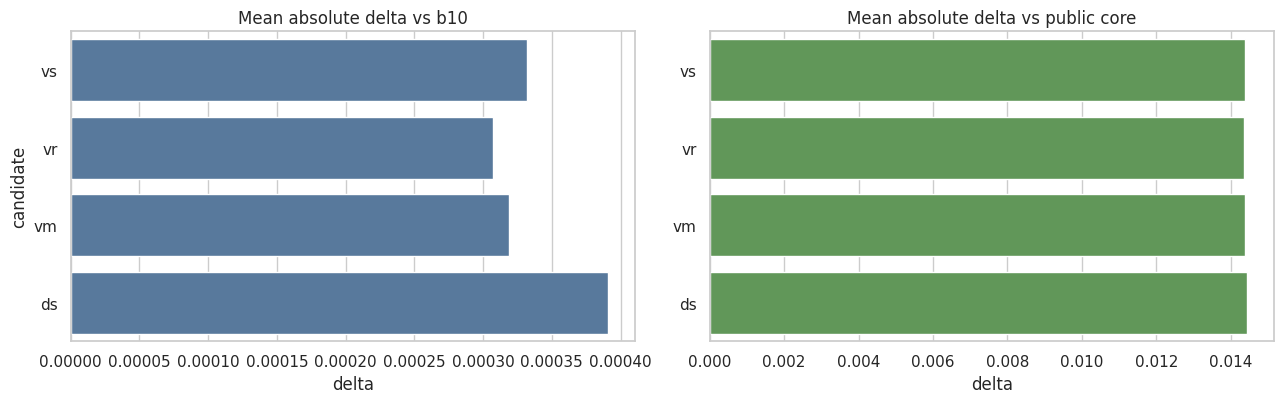

try,key,file,recipe,delta_b10,note
1,b10,submissions/best/b10.csv,0.950 core + 0.050 95381,0.000000,Current best known recipe
2,vs,submissions/catboost_variant/vs.csv,0.945 core + 0.050 95381 + 0.005 shallow,0.000332,Tiny shallow CatBoost injection
3,vr,submissions/catboost_variant/vr.csv,0.945 core + 0.050 95381 + 0.005 reg,0.000307,Tiny regularized CatBoost injection
4,vm,submissions/catboost_variant/vm.csv,0.945 core + 0.050 95381 + 0.0025 shallow + 0.0025 reg,0.000319,Split tiny CatBoost variant injection
5,ds,submissions/public_support/ds.csv,0.945 core + 0.050 95381 + 0.005 95305,0.000391,Tiny support-public injection


In [5]:
"""Visualize how far each candidate moves away from b10 and public core."""

plot_df = readable_summary[readable_summary["key"] != "b10"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
if len(plot_df):
    if sns is not None:
        sns.barplot(data=plot_df, y="key", x="delta_b10", ax=axes[0], color="#4c78a8")
        sns.barplot(data=plot_df, y="key", x="delta_core", ax=axes[1], color="#59a14f")
    else:
        axes[0].barh(plot_df["key"], plot_df["delta_b10"], color="#4c78a8")
        axes[1].barh(plot_df["key"], plot_df["delta_core"], color="#59a14f")
axes[0].set_title("Mean absolute delta vs b10")
axes[0].set_xlabel("delta")
axes[0].set_ylabel("candidate")
axes[1].set_title("Mean absolute delta vs public core")
axes[1].set_xlabel("delta")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

show_table("Submission priority", readable_summary[["try", "key", "file", "recipe", "delta_b10", "note"]], max_rows=len(readable_summary))
